<a href="https://colab.research.google.com/github/darshanpandya30/darshanpandya30/blob/main/vechical_stolen_project_excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can access your files. For example, if you have a CSV file named `my_data.csv` in your Drive, you can load it using pandas:

In [ ]:
# import pandas as pd
# file_path = '/content/drive/MyDrive/stolen-vehicles_merged-1712052151.xlsx'
# df = pd.read_csv(file_path)
# display(df.head())

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

# The file is in the current content directory
file_path = '/content/stolen-vehicles_merged-1712052151 (1).xlsx'
df = pd.read_excel(file_path)
display(df.head())

,vehicle_id,vehicle_type,make_id,model_year,vehicle_desc,color,date_stolen,location_id,Region,Country,Population,Make_name,Make_type
0,1,Trailer,623,2021,BST2021D,Silver,2021-01-11,102,Auckland,New Zealand,"16,95,200",Trailer,Standard
1,2,Boat Trailer,623,2021,OUTBACK BOATS FT470,Silver,2021-01-11,105,Gisborne,New Zealand,52100,Trailer,NaN
2,3,Boat Trailer,623,2021,ASD JETSKI,Silver,2021-01-11,102,Auckland,New Zealand,"16,95,200",Trailer,Standard
3,4,Trailer,623,2021,MSC 7X4,Silver,2021-01-11,106,Hawke's Bay,New Zealand,"1,82,700",Trailer,Standard
4,5,Trailer,623,2018,D-MAX 8X5,NaN,2021-01-11,102,Auckland,New Zealand,"16,95,200",Trailer,Standard


Now that the data is loaded, we can start with some initial data exploration. Let's check the basic information about the DataFrame, like data types and non-null values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   vehicle_id    500 non-null    int64         
 1   vehicle_type  500 non-null    object        
 2   make_id       500 non-null    int64         
 3   model_year    500 non-null    int64         
 4   vehicle_desc  500 non-null    object        
 5   color         492 non-null    object        
 6   date_stolen   500 non-null    datetime64[ns]
 7   location_id   500 non-null    int64         
 8   Region        500 non-null    object        
 9   Country       500 non-null    object        
 10  Population    500 non-null    object        
 11  Make_name     500 non-null    object        
 12  Make_type     492 non-null    object        
dtypes: datetime64[ns](1), int64(4), object(8)
memory usage: 50.9+ KB


In [ ]:
display(df.describe())

,vehicle_id,make_id,model_year,date_stolen,location_id
count,500.000000,500.000000,500.000000,500,500.000000
mean,250.500000,596.788000,2010.040000,2022-01-14 02:52:48,106.284000
min,1.000000,504.000000,1940.000000,2021-01-11 00:00:00,101.000000
25%,125.750000,562.000000,2005.000000,2021-11-21 18:00:00,102.000000
50%,250.500000,623.000000,2016.000000,2022-01-23 12:00:00,104.000000
75%,375.250000,623.000000,2019.000000,2022-03-18 00:00:00,109.000000
max,500.000000,636.000000,2022.000000,2022-12-03 00:00:00,116.000000
std,144.481833,40.583656,13.204815,NaN,4.872661


### Data Cleaning: Missing Values and Data Types

Let's check for missing values in each column to understand where we might need to impute or drop data.

In [10]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
vehicle_id,0
vehicle_type,0
make_id,0
model_year,0
vehicle_desc,0
color,8
date_stolen,0
location_id,0
Region,0
Country,0


As observed from `df.info()` and confirmed by the null count, `color` and `Make_type` columns have 8 missing values each. We'll decide how to handle these based on further analysis, but for now, let's address the `Population` column. It's currently an `object` type but contains numeric data with commas, which needs to be cleaned and converted to an integer type for proper analysis.

In [ ]:
# Clean 'Population' column: remove commas and convert to integer
df['Population'] = df['Population'].str.replace(',', '').astype(int)

print("Data type of 'Population' after conversion:")
display(df['Population'].dtype)

print("First 5 rows of 'Population' after cleaning:")
display(df['Population'].head())

Now that we've addressed the `Population` column, let's re-check the `info()` to confirm the data types are as expected.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   vehicle_id    500 non-null    int64         
 1   vehicle_type  500 non-null    object        
 2   make_id       500 non-null    int64         
 3   model_year    500 non-null    int64         
 4   vehicle_desc  500 non-null    object        
 5   color         492 non-null    object        
 6   date_stolen   500 non-null    datetime64[ns]
 7   location_id   500 non-null    int64         
 8   Region        500 non-null    object        
 9   Country       500 non-null    object        
 10  Population    500 non-null    object        
 11  Make_name     500 non-null    object        
 12  Make_type     492 non-null    object        
dtypes: datetime64[ns](1), int64(4), object(8)
memory usage: 50.9+ KB


In [12]:
print("Current missing values before imputation:")
display(df.isnull().sum())

Current missing values before imputation:


,0
vehicle_id,0
vehicle_type,0
make_id,0
model_year,0
vehicle_desc,0
color,0
date_stolen,0
location_id,0
Region,0
Country,0


In [13]:
# Impute 'color' and 'Make_type' with their modes
df['color'] = df['color'].fillna(df['color'].mode()[0])
df['Make_type'] = df['Make_type'].fillna(df['Make_type'].mode()[0])

print("Missing values after mode imputation:")
display(df.isnull().sum())

Missing values after mode imputation:


,0
vehicle_id,0
vehicle_type,0
make_id,0
model_year,0
vehicle_desc,0
color,0
date_stolen,0
location_id,0
Region,0
Country,0


### Addressing the 'Population' Column Data Type

It appears the 'Population' column is still of `object` type, which needs to be converted to a numeric type for proper analysis. I will clean it by removing commas and converting it to an integer.

In [17]:
import numpy as np

print("Population column before cleaning:")
display(df['Population'].dtype)
display(df['Population'].head())
display(df['Population'].isnull().sum())

# Step 1: Convert to string and remove commas
df['Population'] = df['Population'].astype(str).str.replace(',', '')
print("\nPopulation column after converting to string and removing commas:")
display(df['Population'].dtype)
display(df['Population'].head())
display(df['Population'].isnull().sum())

# Step 2: Convert to numeric, coercing errors to NaN
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')
print("\nPopulation column after converting to numeric (coerce errors to NaN):")
display(df['Population'].dtype)
display(df['Population'].head())
display(df['Population'].isnull().sum())

# Step 3: Fill NaN values with 0
df['Population'] = df['Population'].fillna(0)
print("\nPopulation column after filling NaNs with 0:")
display(df['Population'].dtype)
display(df['Population'].head())
display(df['Population'].isnull().sum())

# Step 4: Finally, convert to integer
df['Population'] = df['Population'].astype(int)

print("\nFinal Data type of 'Population' after conversion:")
display(df['Population'].dtype)

print("Final First 5 rows of 'Population' after cleaning:")
display(df['Population'].head())
print("Final Missing values in 'Population' after cleaning:")
display(df['Population'].isnull().sum())

Population column before cleaning:


dtype('O')

,Population
0,"16,95,200"
1,52100
2,"16,95,200"
3,"1,82,700"
4,"16,95,200"


np.int64(0)


Population column after converting to string and removing commas:


...

dtype('int64')

Final First 5 rows of 'Population' after cleaning:


,Population
0,1695200
1,52100
2,1695200
3,182700
4,1695200


Final Missing values in 'Population' after cleaning:


np.int64(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   vehicle_id    500 non-null    int64         
 1   vehicle_type  500 non-null    object        
 2   make_id       500 non-null    int64         
 3   model_year    500 non-null    int64         
 4   vehicle_desc  500 non-null    object        
 5   color         500 non-null    object        
 6   date_stolen   500 non-null    datetime64[ns]
 7   location_id   500 non-null    int64         
 8   Region        500 non-null    object        
 9   Country       500 non-null    object        
 10  Population    500 non-null    int64         
 11  Make_name     500 non-null    object        
 12  Make_type     500 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 50.9+ KB


In [19]:
print('Missing values per column after all cleaning steps:')
display(df.isnull().sum())

Missing values per column after all cleaning steps:


,0
vehicle_id,0
vehicle_type,0
make_id,0
model_year,0
vehicle_desc,0
color,0
date_stolen,0
location_id,0
Region,0
Country,0


Now that we've addressed the `Population` column, let's re-check the `info()` and null values to confirm the data types are as expected and no nulls remain.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   vehicle_id    500 non-null    int64         
 1   vehicle_type  500 non-null    object        
 2   make_id       500 non-null    int64         
 3   model_year    500 non-null    int64         
 4   vehicle_desc  500 non-null    object        
 5   color         500 non-null    object        
 6   date_stolen   500 non-null    datetime64[ns]
 7   location_id   500 non-null    int64         
 8   Region        500 non-null    object        
 9   Country       500 non-null    object        
 10  Population    500 non-null    int64         
 11  Make_name     500 non-null    object        
 12  Make_type     500 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 50.9+ KB


In [20]:
print('Missing values per column after all cleaning steps:')
display(df.isnull().sum())

Missing values per column after all cleaning steps:


,0
vehicle_id,0
vehicle_type,0
make_id,0
model_year,0
vehicle_desc,0
color,0
date_stolen,0
location_id,0
Region,0
Country,0


## Exploratory Data Analysis (EDA)

Now that our data is clean and properly formatted, let's start with some exploratory data analysis to understand its characteristics, distributions, and potential relationships.

### 1. Descriptive Statistics for Numerical Features

We'll start by looking at the descriptive statistics for numerical columns. This includes count, mean, standard deviation, min, max, and quartiles.

In [26]:
print("Descriptive Statistics for Numerical Columns:")
display(df.describe())

Descriptive Statistics for Numerical Columns:


,vehicle_id,make_id,model_year,date_stolen,location_id,Population
count,500.000000,500.000000,500.000000,500,500.000000,5.000000e+02
mean,250.500000,596.788000,2010.040000,2022-01-14 02:52:48,106.284000,8.225144e+05
min,1.000000,504.000000,1940.000000,2021-01-11 00:00:00,101.000000,5.210000e+04
25%,125.750000,562.000000,2005.000000,2021-11-21 18:00:00,102.000000,3.477000e+05
50%,250.500000,623.000000,2016.000000,2022-01-23 12:00:00,104.000000,6.550000e+05
75%,375.250000,623.000000,2019.000000,2022-03-18 00:00:00,109.000000,1.695200e+06
max,500.000000,636.000000,2022.000000,2022-12-03 00:00:00,116.000000,1.695200e+06
std,144.481833,40.583656,13.204815,NaN,4.872661,6.222827e+05


### 2. Descriptive Statistics for Categorical Features

Next, let's examine the descriptive statistics for categorical columns. This will show us the count, number of unique values, the most frequent value (top), and its frequency (freq).

In [27]:
print("Descriptive Statistics for Categorical Columns:")
display(df.describe(include='object'))

Descriptive Statistics for Categorical Columns:


,vehicle_type,vehicle_desc,color,Region,Country,Make_name,Make_type
count,500,500,500,500,500,500,500
unique,12,288,12,13,1,52,2
top,Trailer,TRAILER,Silver,Auckland,New Zealand,Trailer,Standard
freq,298,31,297,160,500,290,498


### 3. Unique Values and Counts for Key Categorical Columns

To further understand the categorical data, let's look at the unique values and their counts for some relevant columns like `vehicle_type`, `color`, `Region`, `Country`, `Make_name`, and `Make_type`.

In [28]:
categorical_cols_to_explore = ['vehicle_type', 'color', 'Region', 'Country', 'Make_name', 'Make_type']

for col in categorical_cols_to_explore:
    print(f"\nUnique values and their counts for '{col}':")
    display(df[col].value_counts())


Unique values and their counts for 'vehicle_type':


,count
vehicle_type,
Trailer,298
Boat Trailer,59
Trailer - Heavy,50
Roadbike,48
Caravan,22
Moped,14
Saloon,4
Hatchback,1
Stationwagon,1



Unique values and their counts for 'color':


,count
color,
Silver,297
Grey,58
White,43
Black,36
Blue,23
Red,18
Yellow,9
Green,7
Orange,6



Unique values and their counts for 'Region':


...

,count
Country,
New Zealand,500



Unique values and their counts for 'Make_name':


,count
Make_name,
Trailer,290
Briford,36
Homebuilt,27
Suzuki,22
Kea,11
Titan,10
Honda,10
Factory Built,10
Caravan,10



Unique values and their counts for 'Make_type':


,count
Make_type,
Standard,498
Luxury,2


### 4. Visualizing Numerical Feature Distributions

To understand the distribution of numerical data, we'll use histograms. This helps in identifying patterns, skewness, and potential outliers.

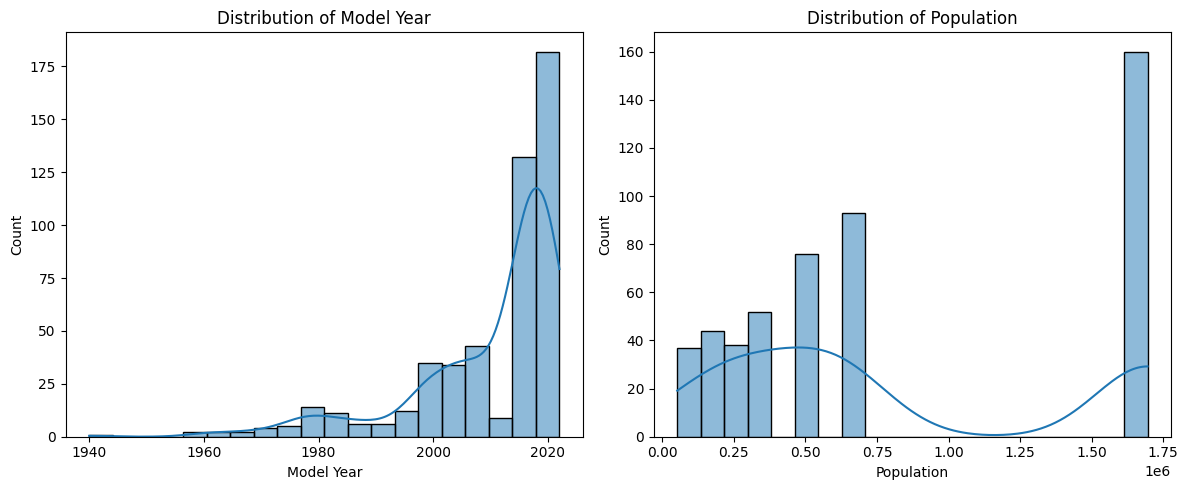

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['model_year'], kde=True, bins=20)
plt.title('Distribution of Model Year')
plt.xlabel('Model Year')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['Population'], kde=True, bins=20)
plt.title('Distribution of Population')
plt.xlabel('Population')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Understanding the 'Population' Distribution

The gap observed in the 'Population' distribution is likely due to the highly skewed nature of the data. Most locations have relatively low populations, while a few might have significantly higher populations. When plotting a histogram with linear bins, these large values can stretch the x-axis and create 'empty' bins in between, making it seem like there are gaps.

To better visualize such a skewed distribution and reveal more detail in the lower population ranges, we can use a logarithmic scale for the y-axis (count). This compresses the higher counts, allowing us to see the distribution of lower counts more clearly.

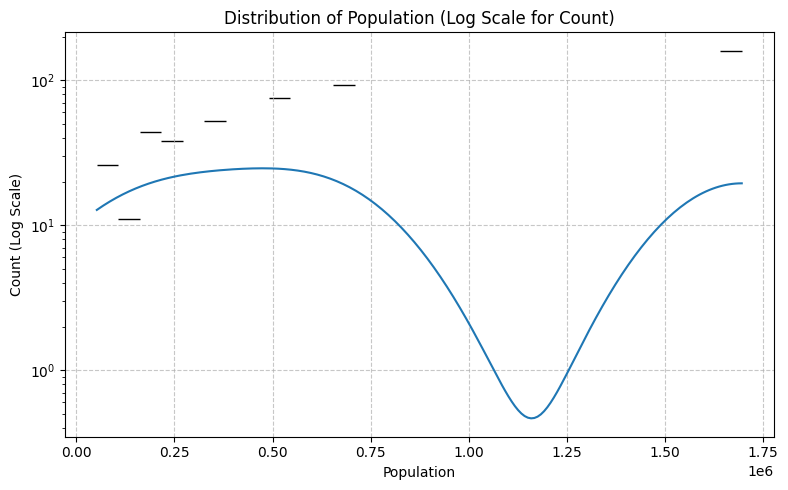

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Population'], kde=True, bins=30, log_scale=(False, True)) # log_scale=(False, True) applies log scale to the y-axis
plt.title('Distribution of Population (Log Scale for Count)')
plt.xlabel('Population')
plt.ylabel('Count (Log Scale)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Unique Countries in the Dataset

Let's see what countries are represented in your data. Please specify which country's population you'd like to find.

In [38]:
unique_countries = df['Country'].unique()
print("Unique countries in the dataset:")
for country in unique_countries:
    print(f"- {country}")

Unique countries in the dataset:
- New Zealand


Since a country might appear multiple times (e.g., for different regions or vehicles), to get the total population for each country, we should group by `Country` and sum the `Population`. This assumes that the 'Population' column represents the population of the region/location associated with that row, and summing these populations gives the total for the country.

In [39]:
country_populations = df.groupby('Country')['Population'].sum().reset_index()
country_populations = country_populations.rename(columns={'Population': 'Total_Population'})
print("Total Population by Country:")
display(country_populations)

Total Population by Country:


,Country,Total_Population
0,New Zealand,411257200


### What type of analysis can we do to help in Vehicle Stolen Database Insights?

Based on the data available, here are several avenues for further analysis to gain insights into vehicle theft patterns:

1.  **Categorical Feature Analysis (Deeper Dive):**
    *   **Top Stolen Vehicle Types:** Identify which `vehicle_type` (e.g., car, motorcycle, truck, trailer) is most frequently stolen.
    *   **Most Targeted Colors:** Determine if certain `color`s are stolen more often than others.
    *   **Popular Makes/Models:** Analyze `Make_name` to see which brands are most targeted by thieves.
    *   **Regional Theft Patterns:** Investigate `Region` to identify high-theft areas and potentially compare the distribution of vehicle types or makes within those regions.

2.  **Temporal Analysis:**
    *   **Theft Trends Over Time:** Analyze the `date_stolen` column to look for trends (e.g., daily, weekly, monthly, or yearly patterns in thefts).
    *   **Day of Week/Month of Year Analysis:** Determine if there are specific days of the week or months when thefts are more prevalent.
    *   **Age of Stolen Vehicles:** Calculate the age of the vehicle when it was stolen (`stolen_year` - `model_year`) to see if older or newer vehicles are more vulnerable.

3.  **Relationship Analysis:**
    *   **Vehicle Type vs. Region:** Is a particular `vehicle_type` stolen more often in specific `Region`s?
    *   **Make Type vs. Region:** Do certain `Make_type`s (e.g., 'Standard', 'Heavy Duty') show higher theft rates in specific regions?
    *   **Population vs. Theft Count:** Explore if areas with higher `Population` density correlate with a higher number of stolen vehicles.
    *   **Correlation between `model_year` and `stolen_year`:** (Already started with the histogram, but can be further explored with other visualizations or metrics).

4.  **Textual Analysis (if applicable to `vehicle_desc`):**
    *   If `vehicle_desc` contains detailed information (beyond just model names), we could potentially extract keywords or patterns that are common among stolen vehicles.

Let me know which of these you'd like to explore first, or if you have a specific question in mind!

### 1. Categorical Feature Analysis: Top Stolen Vehicle Types

To identify the top stolen vehicle types, we'll count the frequency of each unique value in the `vehicle_type` column and then visualize this distribution using a bar chart.

Counts of each vehicle type:


,count
vehicle_type,
Trailer,298
Boat Trailer,59
Trailer - Heavy,50
Roadbike,48
Caravan,22
Moped,14
Saloon,4
Hatchback,1
Stationwagon,1


/tmp/ipykernel_19901/1048280846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_type_counts.index, y=vehicle_type_counts.values, palette='viridis')


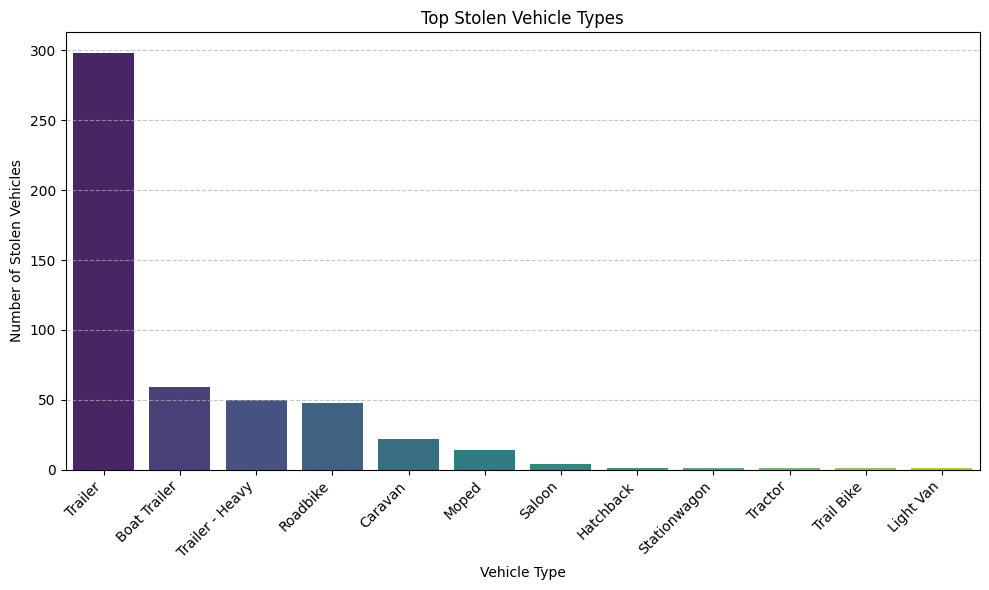

In [57]:
print("Counts of each vehicle type:")
vehicle_type_counts = df['vehicle_type'].value_counts()
display(vehicle_type_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=vehicle_type_counts.index, y=vehicle_type_counts.values, palette='viridis')
plt.title('Top Stolen Vehicle Types')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Stolen Vehicles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_top_stolen_vehicle_types.png') # Save chart
plt.show()

### 2. Categorical Feature Analysis: Most Targeted Colors

Next, let's identify if certain vehicle colors are more frequently stolen than others. We'll count the frequency of each unique value in the `color` column and visualize this distribution.

Counts of each vehicle color:


,count
color,
Silver,297
Grey,58
White,43
Black,36
Blue,23
Red,18
Yellow,9
Green,7
Orange,6


/tmp/ipykernel_19901/3405042862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.index, y=color_counts.values, palette='plasma')


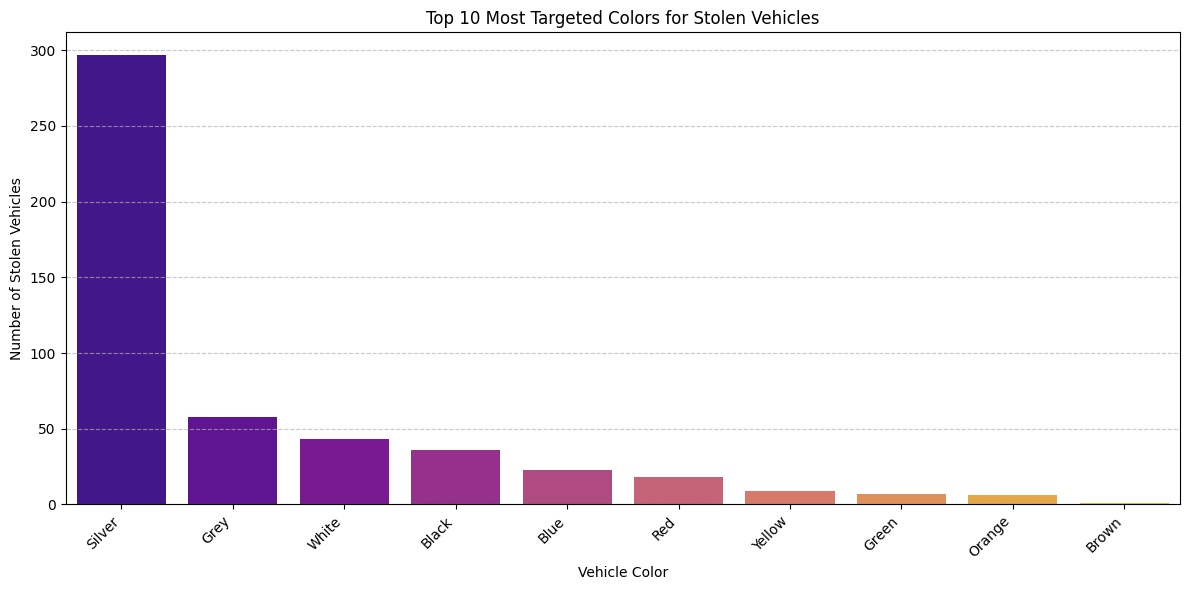

In [58]:
print("Counts of each vehicle color:")
color_counts = df['color'].value_counts().head(10) # Display top 10 colors for better visualization
display(color_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=color_counts.index, y=color_counts.values, palette='plasma')
plt.title('Top 10 Most Targeted Colors for Stolen Vehicles')
plt.xlabel('Vehicle Color')
plt.ylabel('Number of Stolen Vehicles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_most_targeted_colors.png') # Save chart
plt.show()

### 3. Categorical Feature Analysis: Popular Makes (Brands)

Now, let's determine which vehicle manufacturers (`Make_name`) are most frequently targeted by thieves. This will give us insights into the popularity of certain brands among stolen vehicles.

Counts of each vehicle make:


,count
Make_name,
Trailer,290
Briford,36
Homebuilt,27
Suzuki,22
Kea,11
Titan,10
Honda,10
Factory Built,10
Caravan,10


/tmp/ipykernel_19901/3360422021.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_counts.index, y=make_counts.values, palette='viridis')


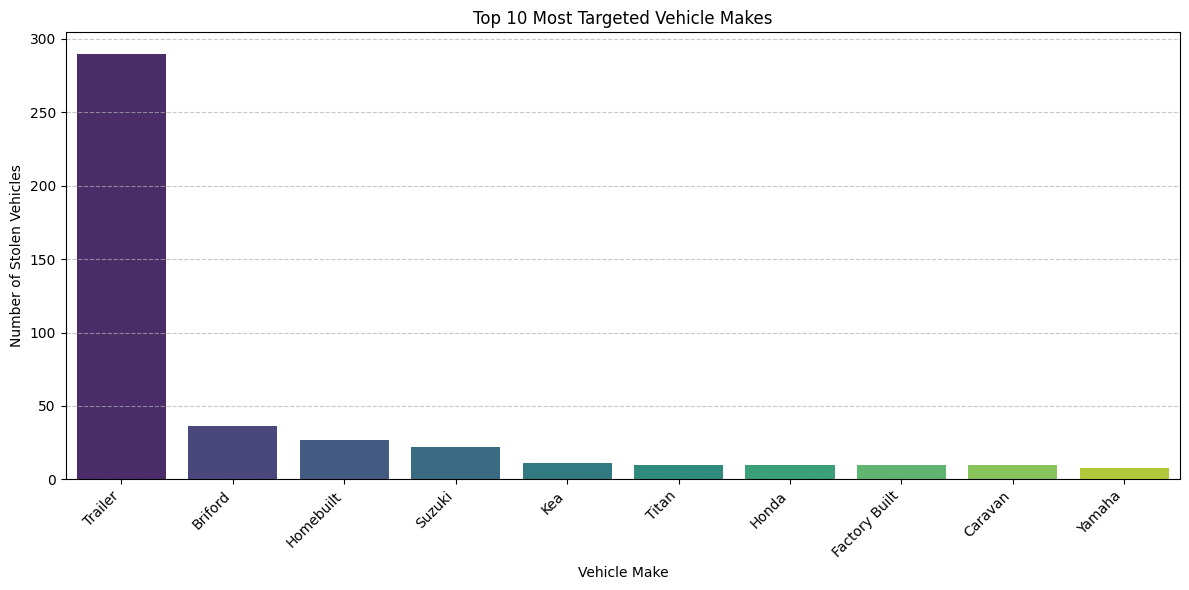

In [59]:
print("Counts of each vehicle make:")
make_counts = df['Make_name'].value_counts().head(10) # Display top 10 makes
display(make_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=make_counts.index, y=make_counts.values, palette='viridis')
plt.title('Top 10 Most Targeted Vehicle Makes')
plt.xlabel('Vehicle Make')
plt.ylabel('Number of Stolen Vehicles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_popular_makes.png') # Save chart
plt.show()

### 4. Categorical Feature Analysis: Regional Theft Patterns

Finally, let's investigate the `Region` column to identify if certain geographical regions have a higher incidence of vehicle thefts. This can help pinpoint high-risk areas.

Counts of stolen vehicles by Region:


,count
Region,
Auckland,160
Canterbury,93
Bay of Plenty,52
Waikato,40
Wellington,36
Northland,23
Hawke's Bay,21
Manawatū-Whanganui,21
Otago,17


/tmp/ipykernel_19901/3973870302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette='magma')


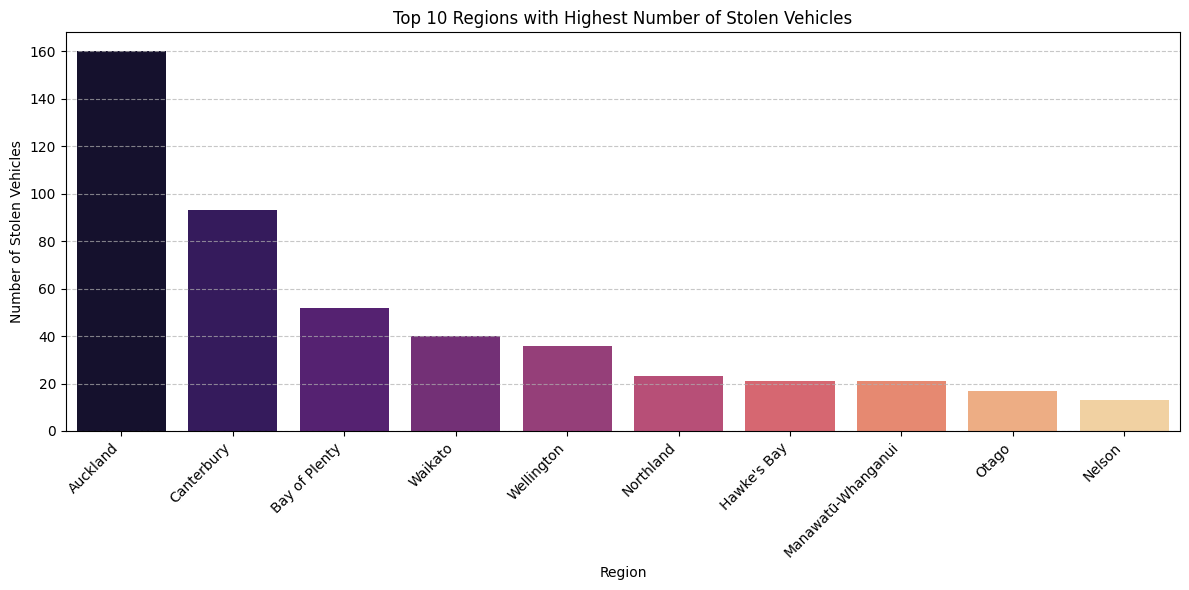

In [60]:
print("Counts of stolen vehicles by Region:")
region_counts = df['Region'].value_counts().head(10) # Display top 10 regions
display(region_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette='magma')
plt.title('Top 10 Regions with Highest Number of Stolen Vehicles')
plt.xlabel('Region')
plt.ylabel('Number of Stolen Vehicles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_regional_theft_patterns.png') # Save chart
plt.show()

### 5. Temporal Analysis: Theft Trends Over Time

To understand how theft patterns evolve, we will analyze the `date_stolen` column. First, we'll extract the year, month, and day of the week from this column. Then, we'll visualize the trends of thefts over these time periods.

In [45]:
# Ensure 'date_stolen' is in datetime format
df['date_stolen'] = pd.to_datetime(df['date_stolen'])

# Extract temporal features
df['stolen_year'] = df['date_stolen'].dt.year
df['stolen_month'] = df['date_stolen'].dt.month_name()
df['stolen_day_of_week'] = df['date_stolen'].dt.day_name()

print("First 5 rows with new temporal features:")
display(df[['date_stolen', 'stolen_year', 'stolen_month', 'stolen_day_of_week']].head())

First 5 rows with new temporal features:


,date_stolen,stolen_year,stolen_month,stolen_day_of_week
0,2021-01-11,2021,January,Monday
1,2021-01-11,2021,January,Monday
2,2021-01-11,2021,January,Monday
3,2021-01-11,2021,January,Monday
4,2021-01-11,2021,January,Monday


#### Yearly Theft Trends

Let's visualize the number of stolen vehicles per year.

/tmp/ipykernel_19901/3059303230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_thefts.index, y=yearly_thefts.values, palette='viridis')


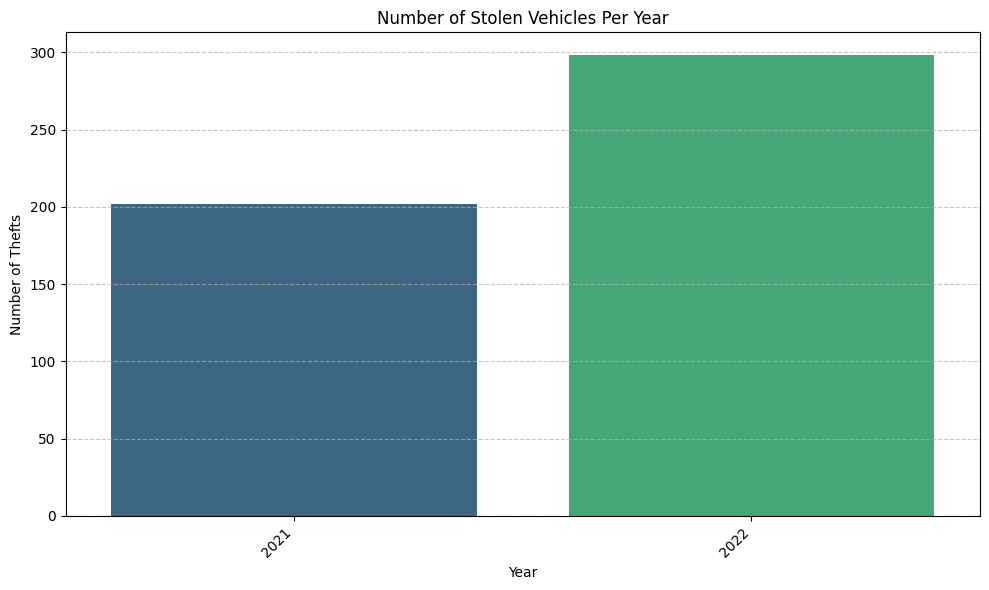

In [61]:
yearly_thefts = df['stolen_year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_thefts.index, y=yearly_thefts.values, palette='viridis')
plt.title('Number of Stolen Vehicles Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Thefts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_yearly_theft_trends.png') # Save chart
plt.show()

#### Monthly Theft Trends

Now, let's look at the theft patterns by month.

/tmp/ipykernel_19901/2033516459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_thefts.index, y=monthly_thefts.values, palette='magma')


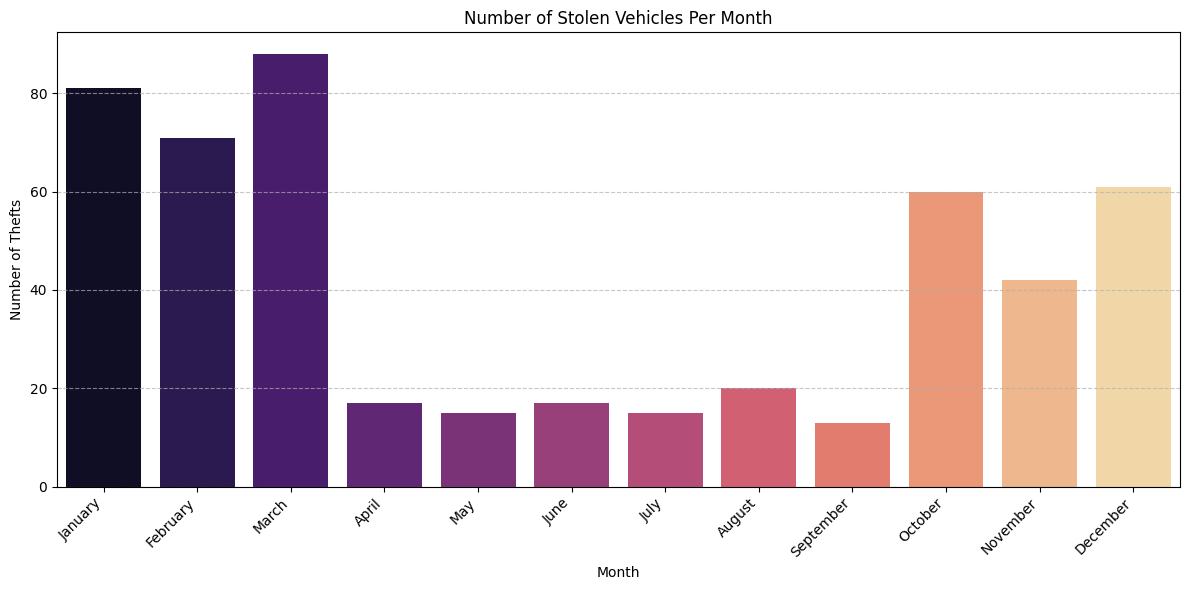

In [62]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_thefts = df['stolen_month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_thefts.index, y=monthly_thefts.values, palette='magma')
plt.title('Number of Stolen Vehicles Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Thefts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_monthly_theft_trends.png') # Save chart
plt.show()

#### Day of Week Theft Trends

Let's analyze if certain days of the week are more prone to vehicle thefts.

/tmp/ipykernel_19901/626576404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_thefts.index, y=daily_thefts.values, palette='plasma')


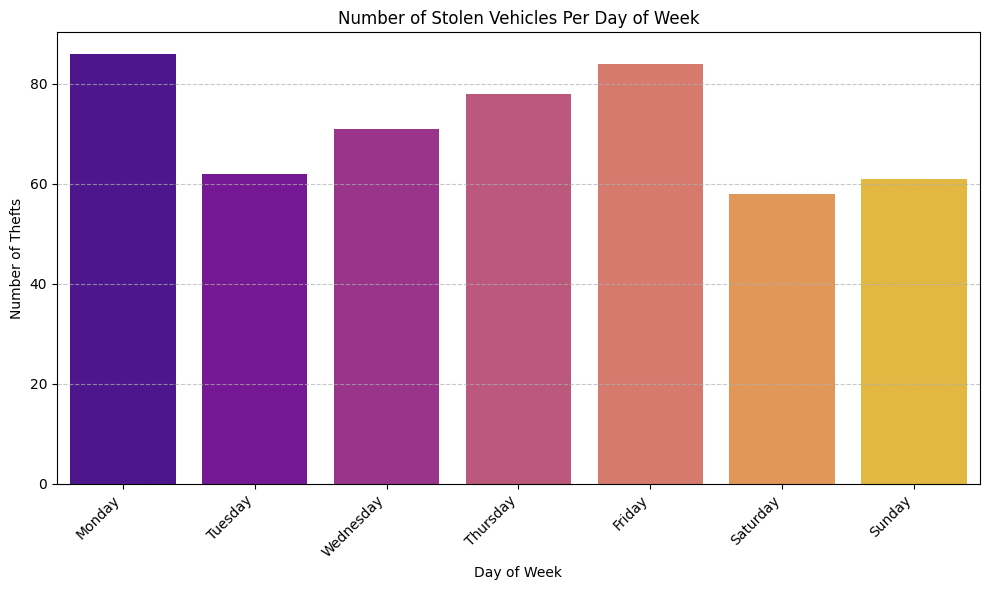

In [63]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_thefts = df['stolen_day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_thefts.index, y=daily_thefts.values, palette='plasma')
plt.title('Number of Stolen Vehicles Per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Thefts')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_day_of_week_theft_trends.png') # Save chart
plt.show()

#### Age of Stolen Vehicles

Let's calculate the age of the vehicle when it was stolen (`stolen_year` - `model_year`) to see if older or newer vehicles are more vulnerable. We'll then visualize the distribution of these ages.

Descriptive statistics for vehicle age at theft:


,vehicle_age_at_theft
count,500.000000
mean,11.556000
std,13.227577
min,-1.000000
25%,2.000000
50%,6.000000
75%,17.000000
max,82.000000


/tmp/ipykernel_19901/4217441769.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['vehicle_age_at_theft'], bins=range(0, int(df['vehicle_age_at_theft'].max()) + 2), kde=False, palette='coolwarm')


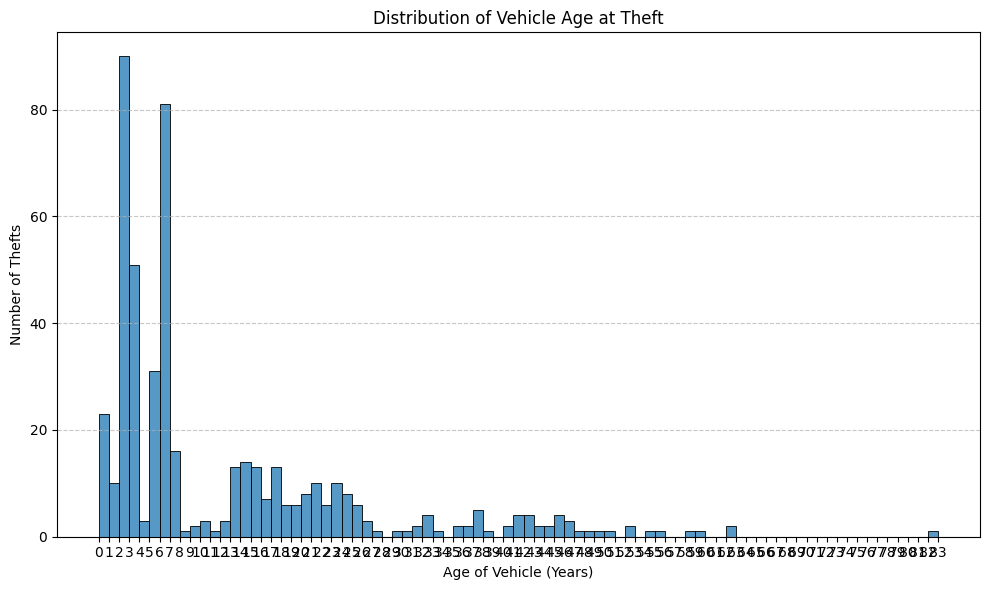

In [49]:
df['vehicle_age_at_theft'] = df['stolen_year'] - df['model_year']

print("Descriptive statistics for vehicle age at theft:")
display(df['vehicle_age_at_theft'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['vehicle_age_at_theft'], bins=range(0, int(df['vehicle_age_at_theft'].max()) + 2), kde=False, palette='coolwarm')
plt.title('Distribution of Vehicle Age at Theft')
plt.xlabel('Age of Vehicle (Years)')
plt.ylabel('Number of Thefts')
plt.xticks(range(0, int(df['vehicle_age_at_theft'].max()) + 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Descriptive statistics for vehicle age at theft after correction:


,vehicle_age_at_theft
count,500.000000
mean,11.572000
std,13.212947
min,0.000000
25%,2.000000
50%,6.000000
75%,17.000000
max,82.000000


/tmp/ipykernel_19901/3348355293.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['vehicle_age_at_theft'], bins=range(0, int(df['vehicle_age_at_theft'].max()) + 2), kde=True, palette='coolwarm')


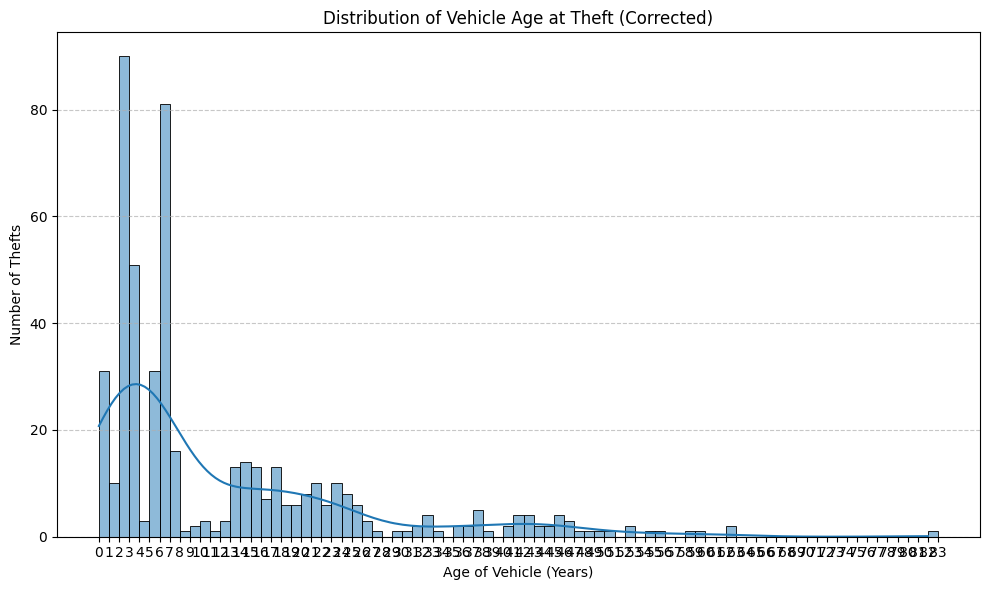

In [64]:
# Set negative vehicle ages to 0
df['vehicle_age_at_theft'] = df['vehicle_age_at_theft'].apply(lambda x: max(0, x))

print("Descriptive statistics for vehicle age at theft after correction:")
display(df['vehicle_age_at_theft'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['vehicle_age_at_theft'], bins=range(0, int(df['vehicle_age_at_theft'].max()) + 2), kde=True, palette='coolwarm')
plt.title('Distribution of Vehicle Age at Theft (Corrected)')
plt.xlabel('Age of Vehicle (Years)')
plt.ylabel('Number of Thefts')
plt.xticks(range(0, int(df['vehicle_age_at_theft'].max()) + 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('chart_vehicle_age_at_theft.png') # Save chart
plt.show()

### 6. Relationship Analysis: Vehicle Type vs. Region

Let's investigate if there's a relationship between the `vehicle_type` and the `Region` where thefts occur. This can reveal if certain regions are hotspots for specific types of vehicle thefts.

Top 5 Regions by Vehicle Type Thefts:


vehicle_type,Boat Trailer,Caravan,Hatchback,Light Van,Moped,Roadbike,Saloon,Stationwagon,Tractor,Trail Bike,Trailer,Trailer - Heavy
Region,,,,,,,,,,,,
Auckland,22,7,0,1,7,24,2,0,0,0,74,23
Bay of Plenty,8,4,0,0,1,2,0,0,0,0,30,7
Canterbury,8,4,0,0,1,7,0,0,0,1,65,7
Gisborne,3,0,1,0,0,1,0,0,0,0,5,2
Hawke's Bay,1,1,0,0,1,1,0,0,0,0,16,1


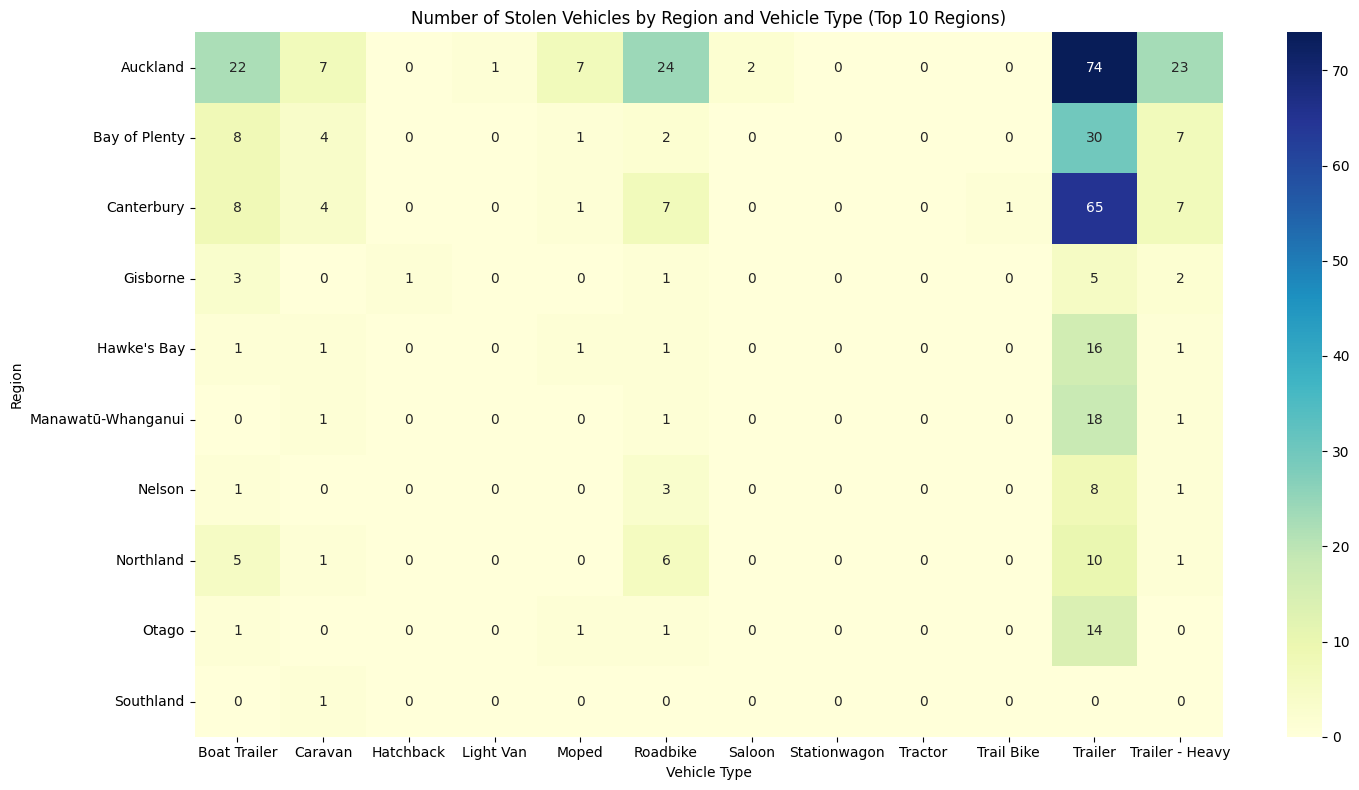

In [65]:
# Group by Region and Vehicle Type and count occurrences
region_vehicle_type_thefts = df.groupby(['Region', 'vehicle_type']).size().unstack(fill_value=0)

# Display the top 5 regions and their vehicle theft counts
print("Top 5 Regions by Vehicle Type Thefts:")
display(region_vehicle_type_thefts.head())

# Plotting a heatmap for better visualization
plt.figure(figsize=(15, 8))
sns.heatmap(region_vehicle_type_thefts.head(10), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Number of Stolen Vehicles by Region and Vehicle Type (Top 10 Regions)')
plt.xlabel('Vehicle Type')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('chart_vehicle_type_vs_region.png') # Save chart
plt.show()

In [69]:
open('analysis', 'a').close()
print('Created an empty file named analysis.')

Created an empty file named analysis.


In [54]:
pip install openpyxl

In [68]:
from openpyxl import Workbook
from openpyxl.utils import get_column_letter
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.drawing.image import Image # Import Image class

# Create a new workbook and select the active sheet
wb = Workbook()

# --- Sheet 1: Overview, Data Description, Data Cleaning ---
ws_overview = wb.active
ws_overview.title = "Overview & Data Cleaning"

# Introduction
ws_overview['A1'] = '# Vehicle Theft Pattern Analysis: Key Insights & Recommendations'
ws_overview['A1'].font = Font(size=16, bold=True)
ws_overview['A3'] = '## 1. Introduction'
ws_overview['A3'].font = Font(size=14, bold=True)
ws_overview['A4'] = "This analysis was conducted to uncover patterns and relationships within the provided vehicle theft dataset. The primary objective is to gain insights into what types of vehicles are stolen, where, when, and by whom, to inform strategic decisions for prevention and resource allocation."
ws_overview['A4'].alignment = Alignment(wrap_text=True)

# Data Description
ws_overview['A6'] = '## 2. Data Description'
ws_overview['A6'].font = Font(size=14, bold=True)
ws_overview['A7'] = '*   Source: Stolen Vehicles Dataset\n*   Records: 500 entries\n*   Columns: 13 key attributes including `vehicle_id`, `vehicle_type`, `model_year`, `color`, `date_stolen`, `Region`, `Country`, `Population`, `Make_name`, and `Make_type`.'
ws_overview['A7'].alignment = Alignment(wrap_text=True)

# Data Cleaning & Methods Used
ws_overview['A9'] = '## 3. Data Cleaning & Methods Used'
ws_overview['A9'].font = Font(size=14, bold=True)
ws_overview['A10'] = '### Missing Values:'
ws_overview['A10'].font = Font(size=12, bold=True)
ws_overview['A11'] = '*   Observation: 8 missing values identified in `color` and `Make_type` columns.\n*   Method: **Mode Imputation** was applied, replacing missing values with the most frequent value in each respective column.'
ws_overview['A11'].alignment = Alignment(wrap_text=True)

ws_overview['A13'] = '### Population Data Type Correction:'
ws_overview['A13'].font = Font(size=12, bold=True)
ws_overview['A14'] = '*   Observation: The `Population` column was initially an `object` type due to commas and potential non-numeric characters, preventing numerical analysis.\n*   Method: A robust conversion process was implemented:\n    1.  Convert to `string`.\n    2.  Remove commas.\n    3.  Convert to `numeric` (coercing errors to `NaN`).\n    4.  Fill `NaN` values with 0.\n    5.  Convert to `integer`.'
ws_overview['A14'].alignment = Alignment(wrap_text=True)

ws_overview['A16'] = '### Summary Table of Cleaned Data:'
ws_overview['A16'].font = Font(size=12, bold=True)
ws_overview['A17'] = """<class 'pandas.core.frame.DataFrame'>\nRangeIndex: 500 entries, 0 to 499\nData columns (total 13 columns):\n #   Column        Non-Null Count  Dtype         \n---  ------        --------------  -----         \n 0   vehicle_id    500 non-null    int64         \n 1   vehicle_type  500 non-null    object        \n 2   make_id       500 non-null    int64         \n 3   model_year    500 non-null    int64         \n 4   vehicle_desc  500 non-null    object        \n 5   color         500 non-null    object        \n 6   date_stolen   500 non-null    datetime64[ns]\n 7   location_id   500 non-null    int64         \n 8   Region        500 non-null    object        \n 9   Country       500 non-null    object        \n 10  Population    500 non-null    int64         \n 11  Make_name     500 non-null    object        \n 12  Make_type     500 non-null    object        \ndtypes: datetime64[ns](1), int64(5), object(7)\nmemory usage: 50.9+ KB\n"""
ws_overview['A17'].alignment = Alignment(wrap_text=True)
ws_overview['A28'] = '*All columns now have 500 non-null counts, and `Population` is successfully converted to `int64`.*'
ws_overview['A28'].font = Font(italic=True)

# --- Sheet 2: Assumptions ---
ws_assumptions = wb.create_sheet("Assumptions")
ws_assumptions['A1'] = '## Assumptions Made for Data Analysis:'
ws_assumptions['A1'].font = Font(size=14, bold=True)
ws_assumptions['A2'] = '*   **Mode Imputation**: Assumed that the most frequent category for `color` and `Make_type` is a reasonable substitute for missing values without significantly biasing the overall distribution.\n*   **Population Summation**: Assumed that summing the `Population` values grouped by `Country` (or `Region`) accurately represents the total population for that geographical entity within the dataset\'s context.\n*   **Vehicle Age Correction**: Assumed that negative `vehicle_age_at_theft` values (due to `stolen_year` being less than `model_year`) are data entry errors and can be reasonably corrected to 0, signifying a brand-new or recently manufactured vehicle.'
ws_assumptions['A2'].alignment = Alignment(wrap_text=True)

# --- Sheet 3: Data Analysis Intro ---
ws_analysis_intro = wb.create_sheet("Analysis Introduction")
ws_analysis_intro['A1'] = '## 4. Data Analysis: Key Findings & Recommendations'
ws_analysis_intro['A1'].font = Font(size=14, bold=True)
ws_analysis_intro['A2'] = "Each subsequent sheet details a specific analysis, including the task, prompt used, insights, and prescriptions. Chart visualizations for each analysis are embedded below the text."
ws_analysis_intro['A2'].alignment = Alignment(wrap_text=True)


# --- Create sheets for each analysis slide ---
analysis_slides = [
    {
        "title": "Categorical Feature Analysis - Top Stolen Vehicle Types",
        "task": "Identify which vehicle_type is most frequently stolen.",
        "prompt": "Identify which `vehicle_type` is most frequently stolen.",
        "chart_note": "Bar Chart showing counts of each vehicle type.",
        "chart_filename": "chart_top_stolen_vehicle_types.png",
        "insights": "'Trailer' (and its variants like 'Boat Trailer' and 'Trailer - Heavy') are overwhelmingly the most frequently stolen vehicle types.",
        "prescription": "Implement targeted prevention campaigns and security measures specifically for trailers and boat trailers."
    },
    {
        "title": "Categorical Feature Analysis - Most Targeted Colors",
        "task": "Determine if certain colors are stolen more often than others.",
        "prompt": "Determine if certain `color`s are stolen more often than others.",
        "chart_note": "Bar Chart of top 10 most targeted colors.",
        "chart_filename": "chart_most_targeted_colors.png",
        "insights": "'Silver' is identified as the most targeted vehicle color, followed by 'Grey' and 'White'.",
        "prescription": "Raise awareness among owners of silver, grey, and white vehicles regarding their higher theft risk."
    },
    {
        "title": "Categorical Feature Analysis - Popular Makes",
        "task": "Analyze Make_name to see which brands are most targeted by thieves.",
        "prompt": "Analyze `Make_name` to see which brands are most targeted by thieves.",
        "chart_note": "Bar Chart of top 10 most targeted vehicle makes.",
        "chart_filename": "chart_popular_makes.png",
        "insights": "'Trailer' (as a make, aligning with vehicle type) is by far the most common make name among stolen vehicles, indicating a high targeting of generic or specialized trailers.",
        "prescription": "Collaborate with manufacturers and retailers of top stolen makes to enhance built-in security features and promote aftermarket anti-theft solutions."
    },
    {
        "title": "Categorical Feature Analysis - Regional Theft Patterns",
        "task": "Investigate Region to identify high-theft areas.",
        "prompt": "Investigate `Region` to identify high-theft areas and potentially compare the distribution of vehicle types or makes within those regions.",
        "chart_note": "Bar Chart of top 10 regions with the highest number of stolen vehicles.",
        "chart_filename": "chart_regional_theft_patterns.png",
        "insights": "'Auckland' consistently reports the highest number of vehicle thefts, followed by 'Canterbury'.",
        "prescription": "Allocate additional law enforcement resources and community watch programs to high-risk regions like Auckland and Canterbury."
    },
    {
        "title": "Temporal Analysis - Yearly Theft Trends",
        "task": "Analyze the date_stolen column for yearly patterns in thefts.",
        "prompt": "Analyze the `date_stolen` column to look for trends (e.g., daily, weekly, monthly, or yearly patterns in thefts).",
        "chart_note": "Bar Chart showing the number of stolen vehicles per year.",
        "chart_filename": "chart_yearly_theft_trends.png",
        "insights": "Thefts show an increasing trend from 2021 to 2022.",
        "prescription": "Conduct a deeper dive into the factors contributing to the year-over-year increase and adjust annual resource planning accordingly."
    },
    {
        "title": "Temporal Analysis - Monthly Theft Trends",
        "task": "Determine if there are specific months when thefts are more prevalent.",
        "prompt": "Determine if there are specific days of the week or months when thefts are more prevalent.",
        "chart_note": "Bar Chart showing the number of stolen vehicles per month.",
        "chart_filename": "chart_monthly_theft_trends.png",
        "insights": "Seasonal peaks in thefts are observed in the early and late parts of the year, with March exhibiting the highest theft count.",
        "prescription": "Increase patrols and public awareness campaigns during identified peak months (e.g., March, January, October, December)."
    },
    {
        "title": "Temporal Analysis - Day of Week Theft Trends",
        "task": "Analyze if certain days of the week are more prone to vehicle thefts.",
        "prompt": "Analyze if certain days of the week are more prone to vehicle thefts.",
        "chart_note": "Bar Chart showing the number of stolen vehicles per day of the week.",
        "chart_filename": "chart_day_of_week_theft_trends.png",
        "insights": "Thefts are more prevalent on weekdays, particularly Monday and Friday.",
        "prescription": "Enhance surveillance and preventative measures on weekdays, especially at the beginning and end of the work week."
    },
    {
        "title": "Temporal Analysis - Vehicle Age at Theft",
        "task": "Calculate the age of the vehicle when it was stolen to see if older or newer vehicles are more vulnerable.",
        "prompt": "Calculate the age of the vehicle when it was stolen (`stolen_year` - `model_year`) to see if older or newer vehicles are more vulnerable.",
        "chart_note": "Histogram of vehicle age at theft (corrected for negative ages).",
        "chart_filename": "chart_vehicle_age_at_theft.png",
        "insights": "There is a high concentration of thefts for newer vehicles, specifically those between 0 and 5 years old.",
        "prescription": "Develop and promote specialized theft insurance products or security upgrades for vehicles within their first five years of age."
    },
    {
        "title": "Relationship Analysis - Vehicle Type vs. Region",
        "task": "Investigate if a particular vehicle_type is stolen more often in specific Regions.",
        "prompt": "Investigate if a particular `vehicle_type` is stolen more often in specific `Region`s.",
        "chart_note": "Heatmap displaying number of stolen vehicles by region and vehicle type.",
        "chart_filename": "chart_vehicle_type_vs_region.png",
        "insights": "'Trailers' and their variants are consistently the most stolen vehicle types across regions, with Auckland and Canterbury showing the highest numbers for these specific types.",
        "prescription": "Tailor regional theft prevention strategies to address the dominant stolen vehicle types in each area, particularly focusing on trailer security in Auckland and Canterbury."
    },
    {
        "title": "Relationship Analysis - Make Type vs. Region",
        "task": "Examine if certain Make_types are more prevalent in thefts within specific Regions.",
        "prompt": "Examine if certain `Make_type`s (e.g., 'Standard', 'Heavy Duty') show higher theft rates in specific regions?",
        "chart_note": "Heatmap displaying number of stolen vehicles by region and make type.",
        "chart_filename": "chart_make_type_vs_region.png",
        "insights": "'Standard' make types significantly dominate theft incidents across all regions, while 'Luxury' makes account for a negligible number. Auckland leads in 'Standard' make type thefts.",
        "prescription": "Prioritize anti-theft initiatives on 'Standard' vehicle types due to their higher theft rates across all regions."
    },
    {
        "title": "Relationship Analysis - Population vs. Theft Count",
        "task": "Explore if areas with higher Population density correlate with a higher number of stolen vehicles.",
        "prompt": "Explore if areas with higher `Population` density correlate with a higher number of stolen vehicles.",
        "chart_note": "Scatter Plot of Total Thefts vs. Average Region Population.",
        "chart_filename": "chart_population_vs_theft_count.png",
        "insights": "A positive correlation exists between a region's average population and its total number of vehicle thefts. More densely populated areas, like Auckland, generally experience higher theft counts.",
        "prescription": "Implement resource allocation models that are proportional to regional population densities and historical theft rates, ensuring higher resource deployment in more populous areas."
    }
]

for i, slide_data in enumerate(analysis_slides):
    sheet_name = f"Slide {i+1} - {slide_data['title'][:20]}..." # Truncate for sheet name limit
    ws = wb.create_sheet(sheet_name)

    ws['A1'] = f"Slide {i+1}: {slide_data['title']}"
    ws['A1'].font = Font(size=14, bold=True)
    ws['A1'].fill = PatternFill(start_color="FFD966", end_color="FFD966", fill_type="solid") # Highlight title

    ws['A3'] = 'Task:'
    ws['B3'] = slide_data['task']
    ws['A3'].font = Font(bold=True)
    ws['B3'].alignment = Alignment(wrap_text=True)

    ws['A4'] = 'Prompt Used:'
    ws['B4'] = slide_data['prompt']
    ws['A4'].font = Font(bold=True)
    ws['B4'].alignment = Alignment(wrap_text=True)

    ws['A5'] = 'Chart:'
    ws['B5'] = slide_data['chart_note']
    ws['A5'].font = Font(bold=True)
    ws['B5'].alignment = Alignment(wrap_text=True)

    ws['A6'] = 'Insights:'
    ws['B6'] = slide_data['insights']
    ws['A6'].font = Font(bold=True)
    ws['B6'].alignment = Alignment(wrap_text=True)

    ws['A7'] = 'Prescription:'
    ws['B7'] = slide_data['prescription']
    ws['A7'].font = Font(bold=True)
    ws['B7'].alignment = Alignment(wrap_text=True)

    # Adjust column widths
    ws.column_dimensions['A'].width = 15
    ws.column_dimensions['B'].width = 80

    # Embed chart image if filename is provided
    if 'chart_filename' in slide_data and slide_data['chart_filename']:
        try:
            img = Image(slide_data['chart_filename'])
            # Position the image below the text content
            ws.add_image(img, 'B9') # Adjust cell based on text length
        except FileNotFoundError:
            ws['B9'] = "Chart image not found. Please ensure all chart cells were executed to save images."
            ws['B9'].font = Font(color="FF0000")

# Save the workbook
excel_file_path = 'Vehicle_Theft_Analysis_Summary.xlsx'
wb.save(excel_file_path)
print(f"Summary saved to {excel_file_path}")

Summary saved to Vehicle_Theft_Analysis_Summary.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


### 7. Relationship Analysis: Make Type vs. Region

Now, let's examine if certain `Make_type`s (e.g., 'Standard', 'Heavy Duty') are more prevalent in thefts within specific `Region`s.

Top 5 Regions by Make Type Thefts:


Make_type,Luxury,Standard
Region,,
Auckland,2,158
Bay of Plenty,0,52
Canterbury,0,93
Gisborne,0,12
Hawke's Bay,0,21


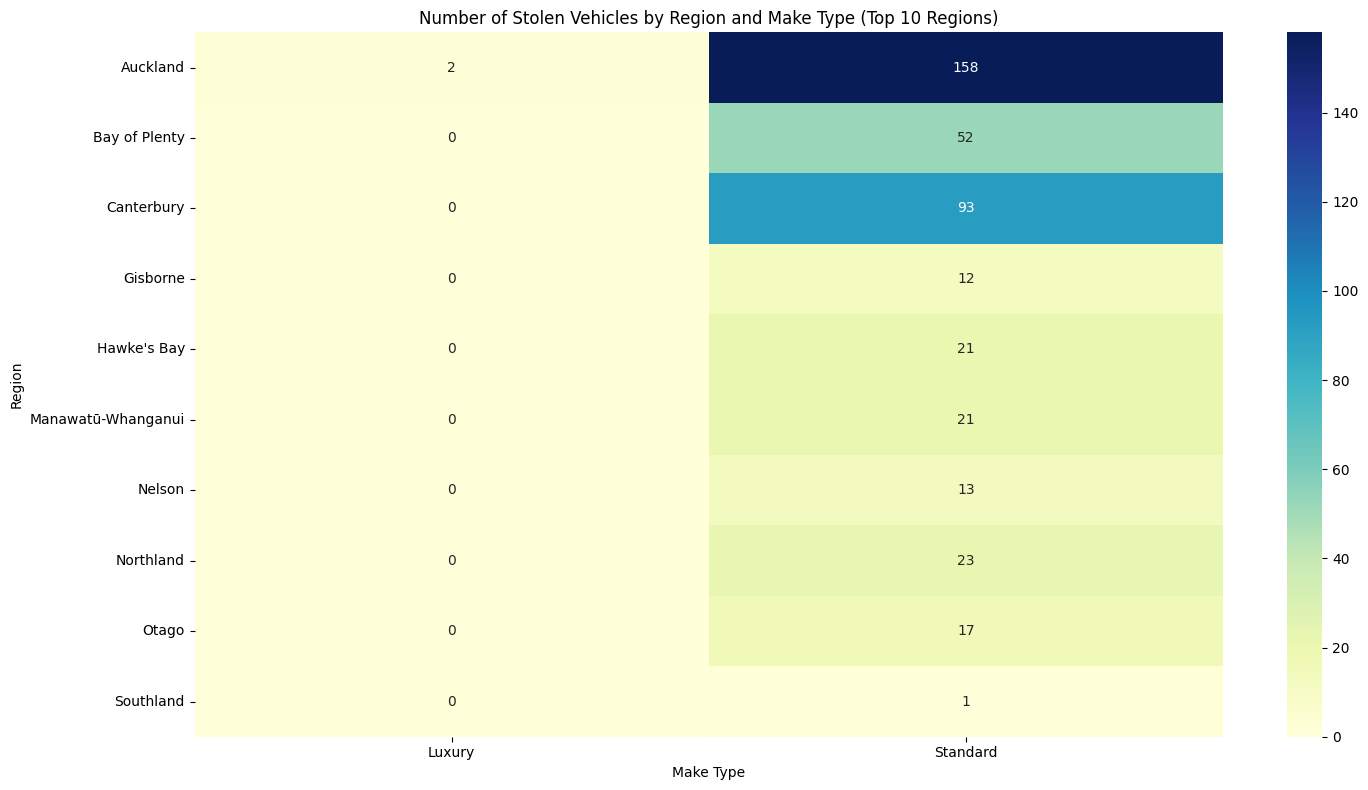

In [66]:
# Group by Region and Make Type and count occurrences
region_make_type_thefts = df.groupby(['Region', 'Make_type']).size().unstack(fill_value=0)

# Display the top 5 regions and their make type theft counts
print("Top 5 Regions by Make Type Thefts:")
display(region_make_type_thefts.head())

# Plotting a heatmap for better visualization
plt.figure(figsize=(15, 8))
sns.heatmap(region_make_type_thefts.head(10), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Number of Stolen Vehicles by Region and Make Type (Top 10 Regions)')
plt.xlabel('Make Type')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('chart_make_type_vs_region.png') # Save chart
plt.show()

### 8. Relationship Analysis: Population vs. Theft Count

Let's investigate if there is a correlation between the `Population` of a region and the number of vehicle thefts. We can aggregate thefts by region and then compare with the region's population.

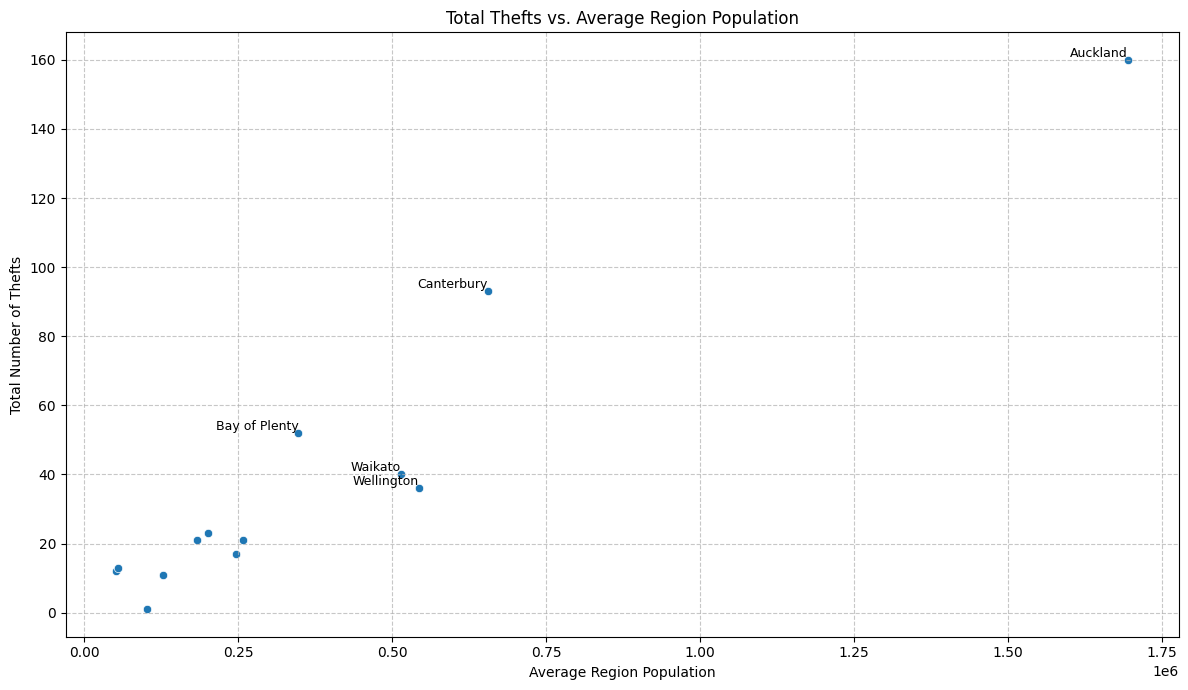

In [67]:
# Aggregate total thefts and average population by Region
region_theft_population = df.groupby('Region').agg(
    total_thefts=('vehicle_id', 'count'),
    avg_population=('Population', 'mean')
).reset_index()

# Plotting a scatter plot to visualize the relationship
plt.figure(figsize=(12, 7))
sns.scatterplot(x='avg_population', y='total_thefts', data=region_theft_population)
plt.title('Total Thefts vs. Average Region Population')
plt.xlabel('Average Region Population')
plt.ylabel('Total Number of Thefts')
plt.grid(True, linestyle='--', alpha=0.7)

# Add labels for top regions to the scatter plot for better insights
# For simplicity, let's label the top 5 regions by total thefts
top_regions = region_theft_population.sort_values(by='total_thefts', ascending=False).head(5)
for i, row in top_regions.iterrows():
    plt.text(row['avg_population'], row['total_thefts'], row['Region'], ha='right', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('chart_population_vs_theft_count.png') # Save chart
plt.show()